In [1]:
# Mount Google Drive to access the dataset. This allows the Colab environment to access files stored in your Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [2]:
# Import standard libraries for file system operations, numerical computing, and plotting.
import os
import numpy as np
import matplotlib.pyplot as plt
import shutil
from PIL import Image

# Import TensorFlow and Keras components for building and training neural networks.
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Import scikit-learn metrics for model evaluation.
from sklearn.metrics import classification_report, confusion_matrix

Dataset Path + Copy to Local

In [3]:
# Import required libraries
import shutil
import os

# Source dataset paths inside Google Drive
src_train = "/content/drive/My Drive/Dataset/Scene Classification/train"
src_test  = "/content/drive/My Drive/Dataset/Scene Classification/test"

# Destination paths inside local Colab runtime
dst_train = "/content/train_data"
dst_test  = "/content/test_data"

# Remove old copied folders if they already exist
# This avoids partial/incomplete dataset copy issues
if os.path.exists(dst_train):
    shutil.rmtree(dst_train)

if os.path.exists(dst_test):
    shutil.rmtree(dst_test)

# Copy training dataset from Google Drive to local Colab storage
shutil.copytree(src_train, dst_train)

# Copy testing dataset from Google Drive to local Colab storage
shutil.copytree(src_test, dst_test)

# Assign local dataset paths to variables
train_dir = dst_train
test_dir = dst_test

# Print confirmation messages
print("Training dataset copied successfully.")
print("Testing dataset copied successfully.")

# Verify that dataset folders exist correctly
print("\nTraining classes:")
print(os.listdir(train_dir))

print("\nTesting classes:")
print(os.listdir(test_dir))

Training dataset copied successfully.
Testing dataset copied successfully.

Training classes:
['forest', 'sea', 'buildings', 'mountain', 'glacier', 'street']

Testing classes:
['forest', 'sea', 'buildings', 'mountain', 'glacier', 'street']


## Dataset Path Verification

This section verifies that the training and testing dataset directories are correctly loaded into the runtime environment. This step helps prevent runtime errors such as `NameError` or missing directory issues during dataset analysis and preprocessing.

In [4]:
# IMPORTANT: Run this cell before dataset analysis cells

train_dir = "/content/train_data"
test_dir = "/content/test_data"

print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Train directory: /content/train_data
Test directory: /content/test_data
Train exists: True
Test exists: True


Dataset Analysis

### Identifying and Removing Invalid Image Files

The `PIL.UnidentifiedImageError` indicates that some files in your dataset directories are not valid image files or are corrupted. The following script will help you find and remove these problematic files from both your training and testing directories.

In [5]:
import os
from PIL import Image, UnidentifiedImageError
import shutil

# Define a function to scan a directory for invalid or corrupted image files and remove them.
def find_and_remove_invalid_images(directory):
    print(f"Scanning directory: {directory}")
    invalid_files = []
    # Walk through all subdirectories and files in the given directory.
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                # Attempt to open and verify the image using PIL.
                with Image.open(file_path) as img:
                    img.verify()  # Verifies that it is an image.
                # Additionally, check for zero-byte files, which are often corrupted.
                if os.path.getsize(file_path) == 0:
                    raise UnidentifiedImageError("Zero-byte file")
            except (UnidentifiedImageError, OSError, Image.DecompressionBombError) as e:
                # If an error occurs, the file is considered invalid.
                print(f"  Invalid file found: {file_path} (Error: {e})")
                invalid_files.append(file_path)

    # Report the findings and offer to remove invalid files.
    if invalid_files:
        print(f"Found {len(invalid_files)} invalid files in {directory}.\n")
        print("Paths of invalid files:")
        for path in invalid_files:
            print(path)

        # Loop to remove each identified invalid file.
        for path in invalid_files:
            os.remove(path)
        print("Invalid files removed.")
    else:
        print(f"No invalid files found in {directory}.\n")
    return invalid_files

# Run the invalid image check and removal process for both training and testing directories.
invalid_train_images = find_and_remove_invalid_images(train_dir)
invalid_test_images = find_and_remove_invalid_images(test_dir)

print("Please review the list of invalid files above. If you are certain these are not valid images, uncomment and run the removal lines in the script above to delete them. After removing, re-run the `ImageDataGenerator` and model training cells.")

Scanning directory: /content/train_data
  Invalid file found: /content/train_data/forest/7595.jpg (Error: cannot identify image file '/content/train_data/forest/7595.jpg')
  Invalid file found: /content/train_data/forest/8162.jpg (Error: cannot identify image file '/content/train_data/forest/8162.jpg')
  Invalid file found: /content/train_data/forest/134.jpg (Error: cannot identify image file '/content/train_data/forest/134.jpg')
  Invalid file found: /content/train_data/forest/5818.jpg (Error: cannot identify image file '/content/train_data/forest/5818.jpg')
  Invalid file found: /content/train_data/forest/1554.jpg (Error: cannot identify image file '/content/train_data/forest/1554.jpg')
  Invalid file found: /content/train_data/forest/6746.jpg (Error: cannot identify image file '/content/train_data/forest/6746.jpg')
  Invalid file found: /content/train_data/forest/11977.jpg (Error: cannot identify image file '/content/train_data/forest/11977.jpg')
  Invalid file found: /content/train

## Total Number of Images

In [6]:
import os

class_counts = {}
total_images = 0

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        image_count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        class_counts[class_name] = image_count
        total_images += image_count

print("Class Counts:")
print(class_counts)

print("Total Training Images:", total_images)

Class Counts:
{'forest': 2264, 'sea': 2267, 'buildings': 2184, 'mountain': 2505, 'glacier': 2397, 'street': 2375}
Total Training Images: 13992


Sample Images

In [7]:
import os

# Initialize a dictionary to store counts for each class.
class_counts = {}

# Iterate through each subdirectory (class) in the training directory.
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    # Ensure it's a directory before counting files within it.
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("Class Counts Calculated.")

Class Counts Calculated.


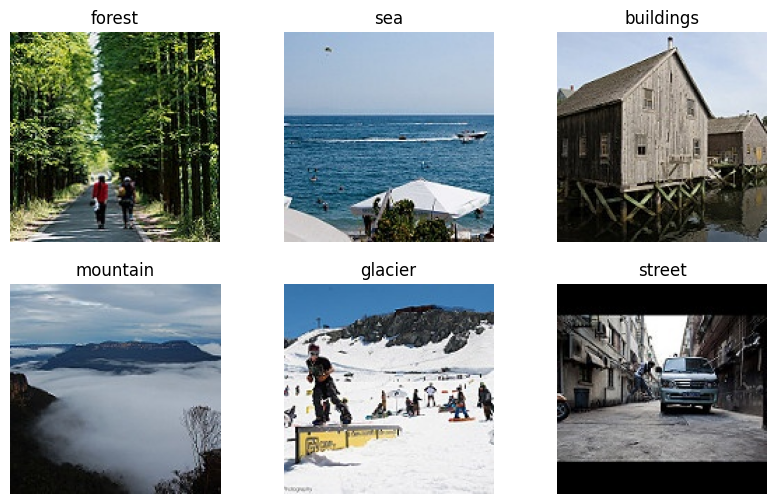

In [8]:
import matplotlib.pyplot as plt

# Get the list of class names from the calculated counts.
class_names = list(class_counts.keys())

# Create a figure to display sample images.
plt.figure(figsize=(10,6))
# Iterate through the first 6 classes to display one sample image from each.
for i, class_name in enumerate(class_names[:6]):
    class_path = os.path.join(train_dir, class_name)
    # Get the name of the first image file in the current class directory.
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    # Open the image using PIL (Pillow).
    img = Image.open(img_path)

    # Create a subplot for each image.
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off') # Hide axes for cleaner image display.

plt.show()

In [10]:
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    print(class_name, len(image_files))

forest 2264
sea 2267
buildings 2184
mountain 2505
glacier 2397
street 2375


Class Distribution

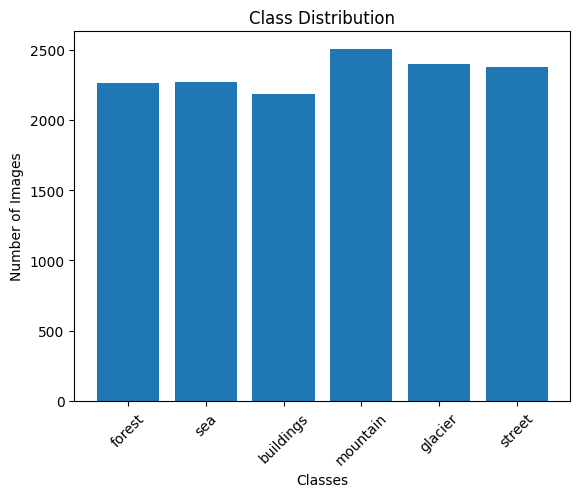

In [11]:
# Re-calculate class counts to ensure it's up-to-date after any data cleaning.
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Create a bar chart to visualize the distribution of images across different classes.
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45) # Rotate x-axis labels for better readability.
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

Data Preprocessing + Generators

In [12]:
# Configure ImageDataGenerator for training data with augmentation and rescaling.
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to [0, 1].
    validation_split=0.2,    # Reserve 20% of the data for validation.
    rotation_range=15,       # Randomly rotate images by up to 15 degrees.
    horizontal_flip=True,    # Randomly flip images horizontally.
    zoom_range=0.2           # Randomly zoom images by up to 20%.
)

# Configure ImageDataGenerator for testing data with only rescaling (no augmentation).
test_datagen = ImageDataGenerator(rescale=1./255)

# Create a generator for training images.
train_generator = train_datagen.flow_from_directory(
    train_dir,                   # Directory containing training data.
    target_size=(224,224),       # Resize all images to 224x224 pixels.
    batch_size=32,               # Number of images to yield in each batch.
    class_mode='categorical',    # For multi-class classification.
    subset='training'            # Specify this as the training subset.
)

# Create a generator for validation images.
val_generator = train_datagen.flow_from_directory(
    train_dir,                   # Directory containing training data.
    target_size=(224,224),       # Resize all images to 224x224 pixels.
    batch_size=32,               # Number of images to yield in each batch.
    class_mode='categorical',    # For multi-class classification.
    subset='validation'          # Specify this as the validation subset.
)

# Create a generator for testing images.
test_generator = test_datagen.flow_from_directory(
    test_dir,                    # Directory containing testing data.
    target_size=(224,224),       # Resize all images to 224x224 pixels.
    batch_size=32,               # Number of images to yield in each batch.
    class_mode='categorical',    # For multi-class classification.
    shuffle=False                # Do not shuffle test data to maintain order for evaluation.
)

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## Augmented Image Visualization

This section displays sample augmented training images generated using ImageDataGenerator. Augmentation helps improve model generalization by creating slightly modified versions of training images.

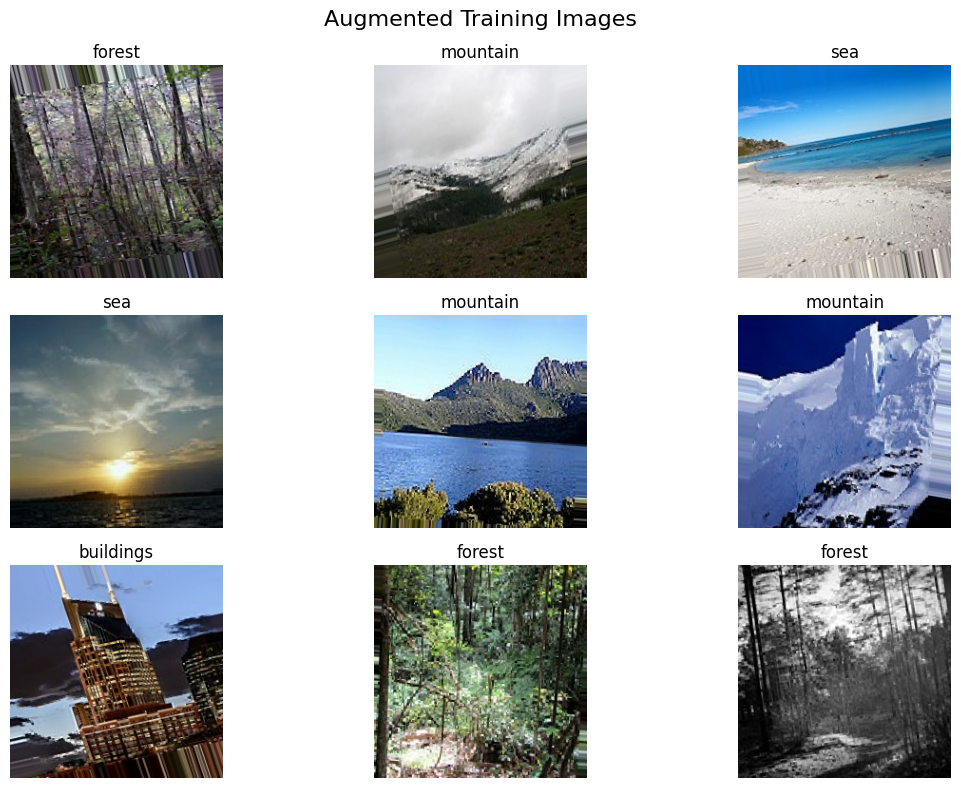

In [13]:
# Visualize augmented images from training generator

import matplotlib.pyplot as plt
import numpy as np

# Get one batch of augmented images
images, labels = next(train_generator)

# Get class names
class_labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Display image
    plt.imshow(images[i])

    # Convert label from one-hot encoding to class name
    label_index = np.argmax(labels[i])
    label_name = class_labels[label_index]

    plt.title(label_name)
    plt.axis("off")

plt.suptitle("Augmented Training Images", fontsize=16)
plt.tight_layout()
plt.show()

Sanity Check

In [14]:
# Get one batch of data from the training generator.
x, y = next(train_generator)
# Print the shape of the image batch (batch_size, height, width, channels) to verify generator output.
print("Batch shape:", x.shape)

Batch shape: (32, 224, 224, 3)


Baseline CNN Model


- Convolution layers extract spatial features from images.
- Pooling layers reduce dimensionality.
- Fully connected layers perform classification.

Activation function: ReLU  
Output layer: Softmax (for multi-class classification)

In [15]:
# Define the Baseline CNN model architecture using Keras Sequential API.
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)), # 32 filters, 3x3 kernel, ReLU activation, input shape for first layer.
    MaxPooling2D(2,2),

    # Second Convolutional Block
    Conv2D(64, (3,3), activation='relu'), # 64 filters, 3x3 kernel, ReLU activation.
    MaxPooling2D(2,2),

    # Third Convolutional Block
    Conv2D(128, (3,3), activation='relu'), # 128 filters, 3x3 kernel, ReLU activation.
    MaxPooling2D(2,2),

    # Flatten the 3D output to 1D for the fully connected layers.
    Flatten(),

    # Fully Connected (Dense) Layers
    Dense(256, activation='relu'), # 256 units, ReLU activation.
    Dense(128, activation='relu'), # 128 units, ReLU activation.
    Dense(64, activation='relu'),  # 64 units, ReLU activation.

    # Output Layer
    Dense(6, activation='softmax') # 6 units (for 6 classes), Softmax activation for probability distribution.
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [16]:
# Compile the model with specified optimizer, loss function, and metrics.
model.compile(
    optimizer='adam',                 # Adam optimizer, often a good default choice.
    loss='categorical_crossentropy',  # Loss function suitable for multi-class classification.
    metrics=['accuracy']              # Metric to monitor during training.
)

Train Model

In [17]:
import time


# Record the start time for training.
start = time.time()

# Train the baseline model using the data generators.
history = model.fit(
    train_generator,       # Training data generator.
    validation_data=val_generator, # Validation data generator for monitoring performance on unseen data.
    epochs=10              # Number of training epochs.
)

# Record the end time and calculate the total training duration.
end = time.time()
baseline_time = end - start
print("Baseline Training Time:", baseline_time)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 192s 525ms/step - accuracy: 0.5774 - loss: 1.0738 - val_accuracy: 0.5998 - val_loss: 1.0434
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 173s 493ms/step - accuracy: 0.7018 - loss: 0.7905 - val_accuracy: 0.7514 - val_loss: 0.6863
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 173s 495ms/step - accuracy: 0.7495 - loss: 0.6762 - val_accuracy: 0.7618 - val_loss: 0.6710
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 491ms/step - accuracy: 0.7924 - loss: 0.5767 - val_accuracy: 0.7915 - val_loss: 0.6079
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 489ms/step - accuracy: 0.8107 - loss: 0.5238 - val_accuracy: 0.8165 - val_loss: 0.5010
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 491ms/step - accuracy: 0.8298 - loss: 0.4676 - val_accuracy: 0.8315 - val_loss: 0.4828
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 173s 493ms/step - accuracy: 0.8330 - loss: 0.4490 - val_accuracy: 0.8230 - val_loss: 0.5109
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 180s 515ms/step - accuracy: 0.8435 -

Plot Accuracy & Loss

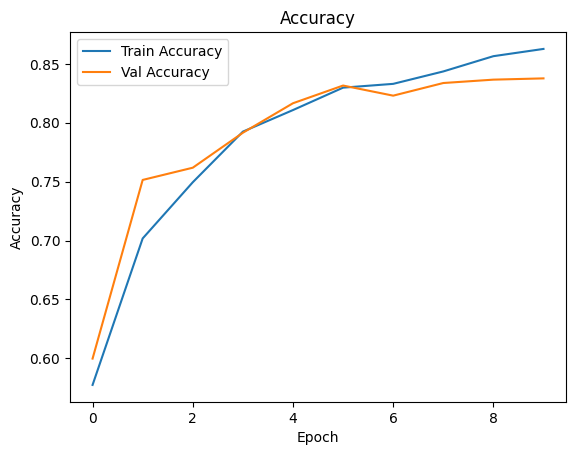

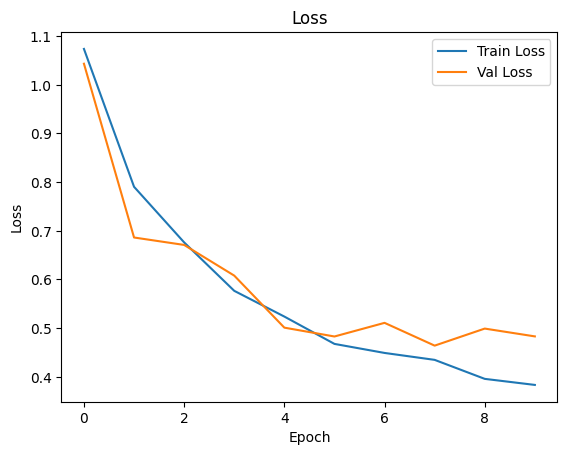

In [18]:
# Plot training and validation accuracy over epochs.
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Plot training and validation loss over epochs.
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Evaluation Metrics

In [19]:
# Make predictions on the test dataset using the trained model.
preds = model.predict(test_generator)
# Get the predicted class labels by selecting the index with the highest probability.
y_pred = preds.argmax(axis=1)

# Print the classification report, which includes precision, recall, and f1-score for each class.
print(classification_report(test_generator.classes, y_pred))

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       437
           1       0.97      0.95      0.96       474
           2       0.85      0.75      0.80       553
           3       0.76      0.85      0.80       525
           4       0.85      0.86      0.86       510
           5       0.88      0.89      0.89       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



## Baseline CNN Model Summary

The following summary provides detailed information about the baseline CNN architecture, including the number of layers, output shapes, and trainable parameters. This helps in understanding the complexity of the model.

In [20]:
# Display baseline CNN model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,858,644 (255.05 MB)

 Trainable params: 22,286,214 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,572,430 (170.03 MB)

## Sample Predictions using Baseline CNN
This section performs inference on sample test images using the trained baseline CNN model. The actual and predicted class labels are visualized to qualitatively evaluate model performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step


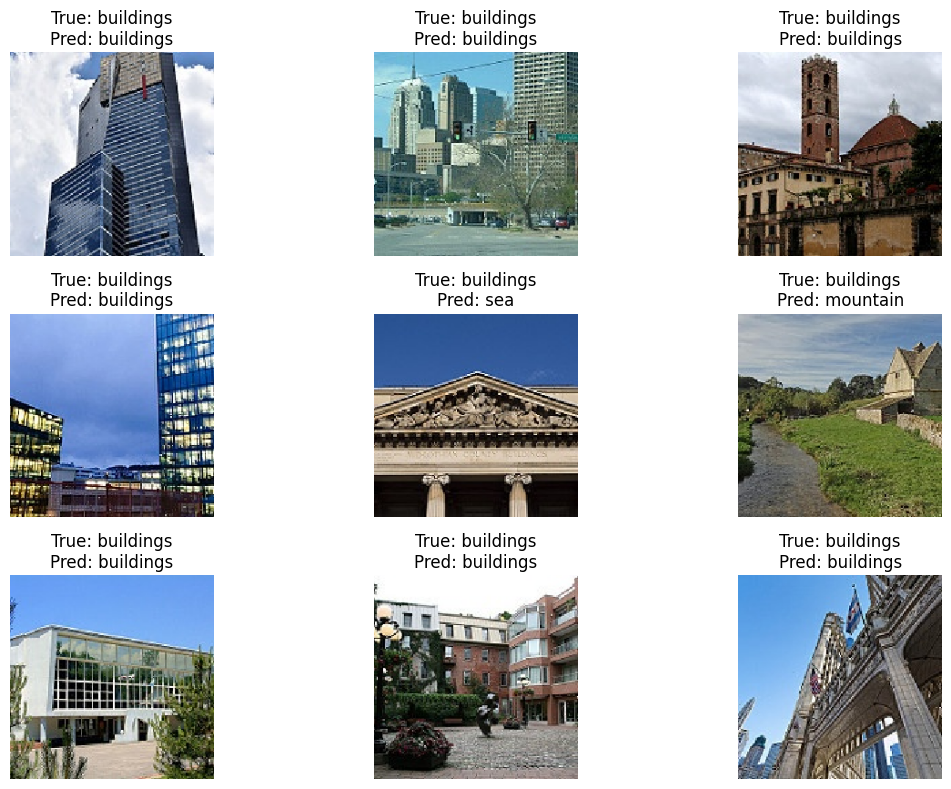

In [21]:
# Display sample predictions from baseline CNN

import matplotlib.pyplot as plt
import numpy as np

test_generator.reset()

images, labels = next(test_generator)

predictions = model.predict(images)

class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(12,8))

for i in range(min(9, len(images))):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    true_label = class_labels[np.argmax(labels[i])]
    predicted_label = class_labels[np.argmax(predictions[i])]

    plt.title(f"True: {true_label}\nPred: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Baseline CNN Confusion Matrix


## Baseline CNN Confusion Matrix

This confusion matrix shows how well the baseline CNN classified each scene category and highlights misclassification patterns between similar classes.

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step
Baseline CNN Classification Report:
              precision    recall  f1-score   support

   buildings       0.84      0.85      0.85       437
      forest       0.97      0.95      0.96       474
     glacier       0.85      0.75      0.80       553
    mountain       0.76      0.85      0.80       525
         sea       0.85      0.86      0.86       510
      street       0.88      0.89      0.89       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000



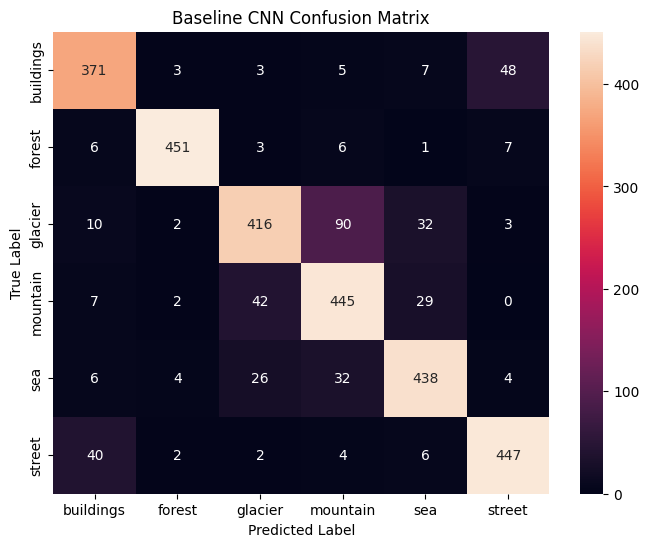

In [22]:
# Confusion matrix for Baseline CNN

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset test generator
test_generator.reset()

# Predict using baseline model
baseline_predictions = model.predict(test_generator)

# Convert predicted probabilities into class labels
baseline_pred_classes = np.argmax(baseline_predictions, axis=1)

# True labels
true_classes = test_generator.classes

# Class names
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("Baseline CNN Classification Report:")
print(classification_report(true_classes, baseline_pred_classes, target_names=class_labels))

# Create confusion matrix
baseline_cm = confusion_matrix(true_classes, baseline_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [23]:
# Define a Deeper CNN model with Batch Normalization and Dropout layers for regularization.
model2 = Sequential([
    # First Convolutional Block
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(), # Normalize activations of the previous layer.
    MaxPooling2D(),

    # Second Convolutional Block
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    # Third Convolutional Block
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    # Fourth Convolutional Block
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(),

    # Flatten the 3D output to 1D for the fully connected layers.
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Apply Dropout for regularization to prevent overfitting.
    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train Deeper Model

In [24]:
import time

# Record the start time for training the deeper model.
start = time.time()
# Compile the deeper model with the Adam optimizer, categorical crossentropy loss, and accuracy metric.
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the deeper model using the data generators.
history2 = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)
# Record the end time and calculate the total training duration.
end = time.time()
baseline_time = end - start
print("Baseline Training Time:", baseline_time)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 187s 513ms/step - accuracy: 0.4942 - loss: 1.8570 - val_accuracy: 0.2207 - val_loss: 2.6435
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 177s 505ms/step - accuracy: 0.6258 - loss: 0.9809 - val_accuracy: 0.6398 - val_loss: 0.9535
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 176s 501ms/step - accuracy: 0.7014 - loss: 0.8245 - val_accuracy: 0.6831 - val_loss: 0.9414
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 175s 501ms/step - accuracy: 0.7429 - loss: 0.7167 - val_accuracy: 0.7171 - val_loss: 0.7465
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 177s 507ms/step - accuracy: 0.7658 - loss: 0.6678 - val_accuracy: 0.7758 - val_loss: 0.6531
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 176s 503ms/step - accuracy: 0.7788 - loss: 0.6271 - val_accuracy: 0.6760 - val_loss: 0.8427
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 174s 497ms/step - accuracy: 0.7898 - loss: 0.5942 - val_accuracy: 0.7546 - val_loss: 0.6652
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 177s 505ms/step - accuracy: 0.7970 -

Optimizer Comparison

> Adam converges faster and provides better accuracy compared to SGD.  
SGD may require more epochs but can generalize better in some cases.



Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 183s 509ms/step - accuracy: 0.6074 - loss: 1.2602 - val_accuracy: 0.4295 - val_loss: 1.5939
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 173s 493ms/step - accuracy: 0.7157 - loss: 0.7566 - val_accuracy: 0.6524 - val_loss: 1.0085
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 181s 517ms/step - accuracy: 0.7555 - loss: 0.6560 - val_accuracy: 0.7396 - val_loss: 0.7385
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 173s 494ms/step - accuracy: 0.7854 - loss: 0.5876 - val_accuracy: 0.7049 - val_loss: 0.7676
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 519ms/step - accuracy: 0.8016 - loss: 0.5416 - val_accuracy: 0.7643 - val_loss: 0.6671
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 182s 519ms/step - accuracy: 0.8149 - loss: 0.5075 - val_accuracy: 0.7082 - val_loss: 0.8190
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 175s 499ms/step - accuracy: 0.8303 - loss: 0.4618 - val_accuracy: 0.7840 - val_loss: 0.6302
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 492ms/step - accuracy: 0.8405 -

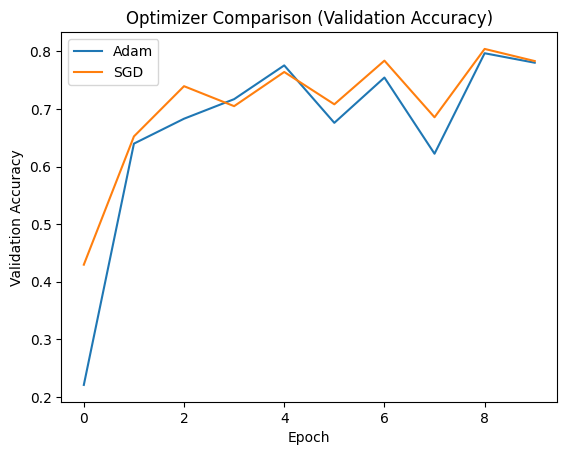

In [25]:

# Reuse the deeper model architecture for comparison with SGD optimizer.
model_sgd = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(6, activation='softmax') # Output layer for 6 classes.
])

# Compile the model specifically with the SGD optimizer.
model_sgd.compile(
    optimizer='sgd', # Stochastic Gradient Descent optimizer.
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model with SGD optimizer.
history_sgd = model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# Plot and compare the validation accuracy of models trained with Adam (history2) and SGD (history_sgd).
plt.plot(history2.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

Ablation Study

Removing dropout led to increased overfitting.  
Dropout helps improve generalization by preventing the model from memorizing training data.

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 186s 516ms/step - accuracy: 0.4568 - loss: 5.2227 - val_accuracy: 0.4410 - val_loss: 24.2996
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 169s 482ms/step - accuracy: 0.5844 - loss: 1.2353 - val_accuracy: 0.5669 - val_loss: 1.1614
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 169s 483ms/step - accuracy: 0.6290 - loss: 0.9933 - val_accuracy: 0.3208 - val_loss: 4.5079
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 179s 511ms/step - accuracy: 0.6917 - loss: 0.8344 - val_accuracy: 0.6949 - val_loss: 0.8758
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 171s 490ms/step - accuracy: 0.7350 - loss: 0.7581 - val_accuracy: 0.7146 - val_loss: 0.8583
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 170s 487ms/step - accuracy: 0.7220 - loss: 0.8722 - val_accuracy: 0.4757 - val_loss: 2.2599
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 172s 492ms/step - accuracy: 0.7354 - loss: 0.7635 - val_accuracy: 0.6484 - val_loss: 1.0577
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 171s 488ms/step - accuracy: 0.7618 

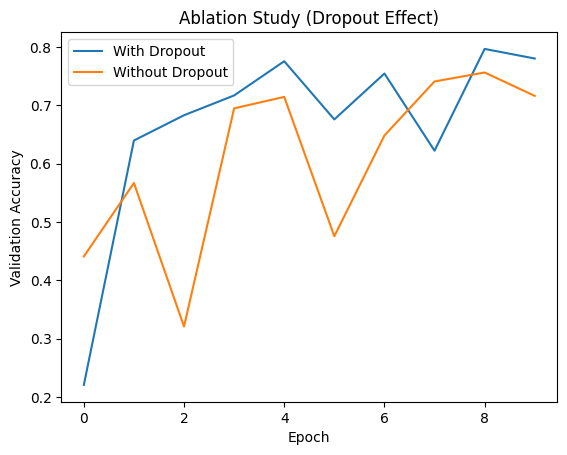

In [26]:

# Define a model similar to the deeper model but WITHOUT a Dropout layer for an ablation study.
model_no_dropout = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(6, activation='softmax')
])

# Compile the model without dropout.
model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model without dropout.
history_no_dropout = model_no_dropout.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

# Compare the validation accuracy of the model with dropout (history2) and without dropout (history_no_dropout).
plt.plot(history2.history['val_accuracy'], label='With Dropout')
plt.plot(history_no_dropout.history['val_accuracy'], label='Without Dropout')

plt.title("Ablation Study (Dropout Effect)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

## Deeper CNN Model Summary
The following summary shows the architecture of the deeper CNN model with additional convolutional layers and regularization techniques such as Batch Normalization and Dropout.

In [27]:
# Display deeper CNN model summary

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,483,988 (112.47 MB)

 Trainable params: 9,827,846 (37.49 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 19,655,694 (74.98 MB)

## Deeper CNN Confusion Matrix

This confusion matrix evaluates the deeper CNN model with regularization. It helps compare whether the deeper model reduced or increased misclassifications compared with the baseline CNN.

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step
Deeper CNN Classification Report:
              precision    recall  f1-score   support

   buildings       0.73      0.82      0.77       437
      forest       0.98      0.78      0.87       474
     glacier       0.79      0.75      0.77       553
    mountain       0.85      0.60      0.70       525
         sea       0.70      0.87      0.78       510
      street       0.71      0.85      0.77       501

    accuracy                           0.78      3000
   macro avg       0.79      0.78      0.78      3000
weighted avg       0.79      0.78      0.78      3000



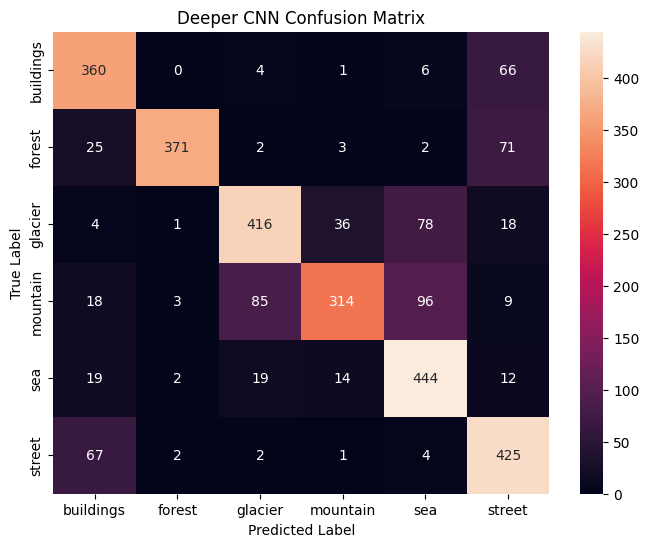

In [28]:
# Confusion matrix for Deeper CNN

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset test generator
test_generator.reset()

# Predict using deeper CNN model
deeper_predictions = model2.predict(test_generator)

# Convert predicted probabilities into class labels
deeper_pred_classes = np.argmax(deeper_predictions, axis=1)

# True labels
true_classes = test_generator.classes

# Class names
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("Deeper CNN Classification Report:")
print(classification_report(true_classes, deeper_pred_classes, target_names=class_labels))

# Create confusion matrix
deeper_cm = confusion_matrix(true_classes, deeper_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    deeper_cm,
    annot=True,
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Deeper CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Baseline vs Deeper CNN Performance Comparison

This section compares the performance of the baseline CNN and deeper CNN models using validation accuracy and validation loss curves. The comparison helps analyze whether increasing network depth improves classification performance.


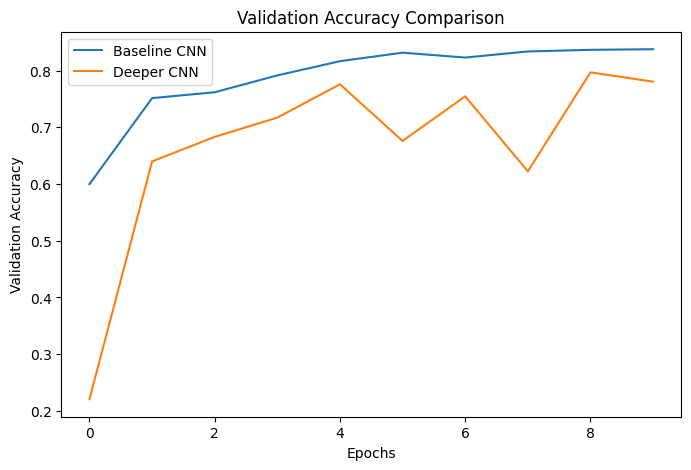

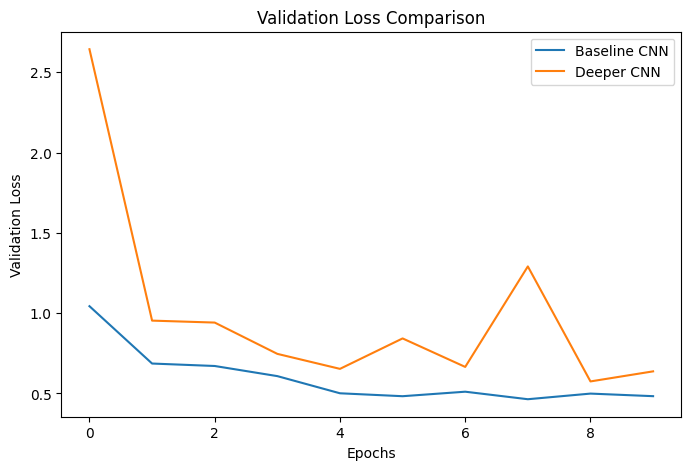

In [29]:
# Compare validation accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['val_accuracy'], label='Baseline CNN')
plt.plot(history2.history['val_accuracy'], label='Deeper CNN')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.show()

# Compare validation loss

plt.figure(figsize=(8,5))

plt.plot(history.history['val_loss'], label='Baseline CNN')
plt.plot(history2.history['val_loss'], label='Deeper CNN')

plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()

plt.show()

Transfer Learning

In [30]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense
import time


# Load Pretrained Model

# Load the VGG16 model, pre-trained on ImageNet.
# include_top=False: Exclude the top classification layer.
# input_shape=(224,224,3): Specify the input image dimensions.
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze all layers in the base VGG16 model.
# This prevents their weights from being updated during training, using VGG16 as a fixed feature extractor.
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the frozen base model.
x = Flatten()(base_model.output) # Flatten the output of the VGG16 convolutional base.
x = Dense(128, activation='relu')(x) # Add a Dense layer with ReLU activation.
output = Dense(6, activation='softmax')(x) # Add the final output layer for 6 classes with Softmax activation.

# Create the new model combining the VGG16 base and the custom classification head.
model3 = Model(inputs=base_model.input, outputs=output)

# Compile the transfer learning model.
model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Training (Feature Extraction)

# Record the start time for training the transfer learning model.
start = time.time()

history3 = model3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5 # Train for fewer epochs as transfer learning often converges faster.
)

# Record the end time and calculate the total training duration.
end = time.time()
transfer_time = end - start

print("Transfer Learning Time:", transfer_time)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 227s 606ms/step - accuracy: 0.8057 - loss: 0.5819 - val_accuracy: 0.8451 - val_loss: 0.4084
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 190s 543ms/step - accuracy: 0.8633 - loss: 0.3736 - val_accuracy: 0.8659 - val_loss: 0.3829
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 191s 545ms/step - accuracy: 0.8828 - loss: 0.3162 - val_accuracy: 0.8577 - val_loss: 0.3836
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 189s 541ms/step - accuracy: 0.8909 - loss: 0.3020 - val_accuracy: 0.8673 - val_loss: 0.3722
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 191s 545ms/step - accuracy: 0.8989 - loss: 0.2717 - val_accuracy: 0.8666 - val_loss: 0.3605
Transfer Learning Time: 999.8153178691864


## Transfer Learning Model Summary

The following summary presents the architecture of the transfer learning model based on VGG16. The convolutional base is frozen while new dense layers are added for custom image classification.

In [31]:
# Display transfer learning model summary

model3.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,351,188 (92.89 MB)

 Trainable params: 3,212,166 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 6,424,334 (24.51 MB)

## Evaluation of Transfer Learning Model

The transfer learning model is evaluated using classification metrics such as precision, recall, F1-score, and confusion matrix. These metrics help assess the effectiveness of transfer learning compared to CNN models trained from scratch.

94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 279ms/step
Classification Report for Transfer Learning Model:

              precision    recall  f1-score   support

   buildings       0.94      0.85      0.89       437
      forest       0.97      0.98      0.98       474
     glacier       0.78      0.88      0.82       553
    mountain       0.86      0.72      0.78       525
         sea       0.90      0.88      0.89       510
      street       0.86      0.97      0.91       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



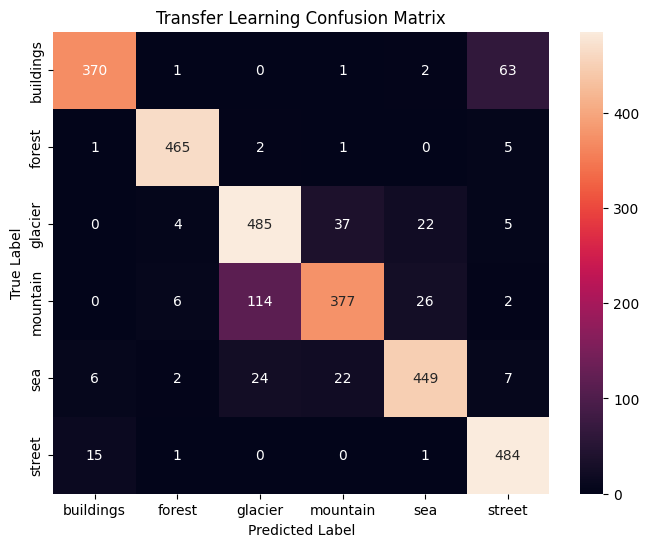

In [32]:
# Evaluate transfer learning model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

test_generator.reset()

preds_tl = model3.predict(test_generator)

y_pred_tl = np.argmax(preds_tl, axis=1)
y_true_tl = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("Classification Report for Transfer Learning Model:\n")

print(classification_report(
    y_true_tl,
    y_pred_tl,
    target_names=class_labels
))

# Confusion Matrix

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_tl,
    annot=True,
    fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Final Comparison of All Models

This section compares the validation accuracy of all implemented models, including the baseline CNN, deeper CNN, and transfer learning model. This comparison helps identify the best-performing architecture for the image classification task.

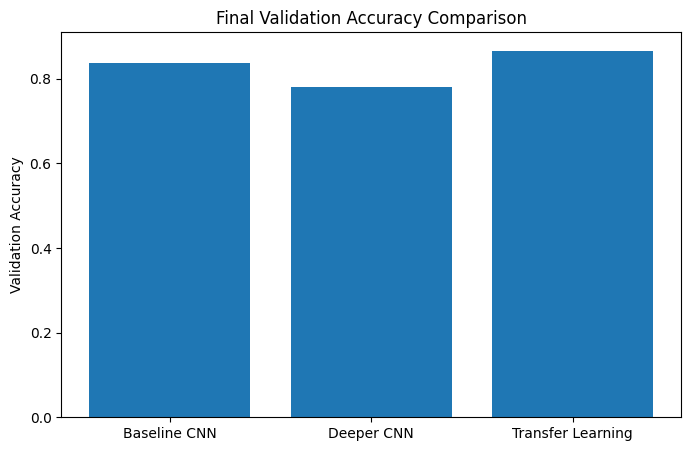

Baseline CNN Accuracy: 0.8376252055168152
Deeper CNN Accuracy: 0.7804005742073059
Transfer Learning Accuracy: 0.8665951490402222


In [33]:
# Final model comparison

baseline_acc = history.history['val_accuracy'][-1]
deeper_acc = history2.history['val_accuracy'][-1]
transfer_acc = history3.history['val_accuracy'][-1]

models = ['Baseline CNN', 'Deeper CNN', 'Transfer Learning']
accuracies = [baseline_acc, deeper_acc, transfer_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Final Validation Accuracy Comparison")
plt.ylabel("Validation Accuracy")

plt.show()

print("Baseline CNN Accuracy:", baseline_acc)
print("Deeper CNN Accuracy:", deeper_acc)
print("Transfer Learning Accuracy:", transfer_acc)

Final Model Performance Comparison
----------------------------------
Baseline CNN              - Best Val Accuracy: 0.8376, Best Val Loss: 0.4641
Deeper CNN                - Best Val Accuracy: 0.7969, Best Val Loss: 0.5749
VGG16 Transfer Learning   - Best Val Accuracy: 0.8673, Best Val Loss: 0.3605


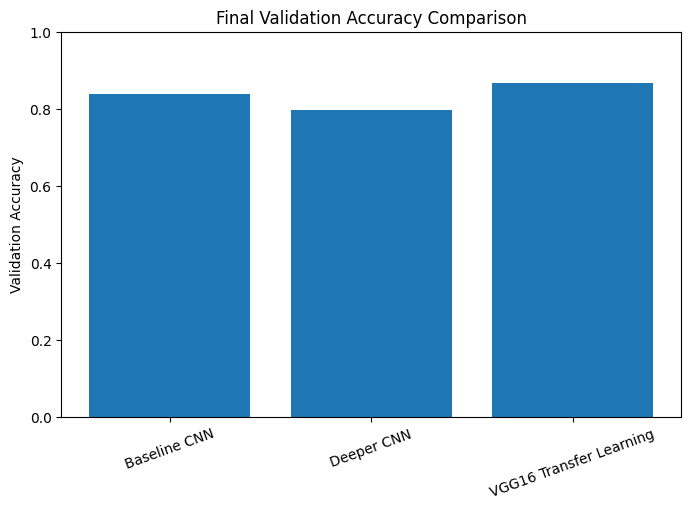

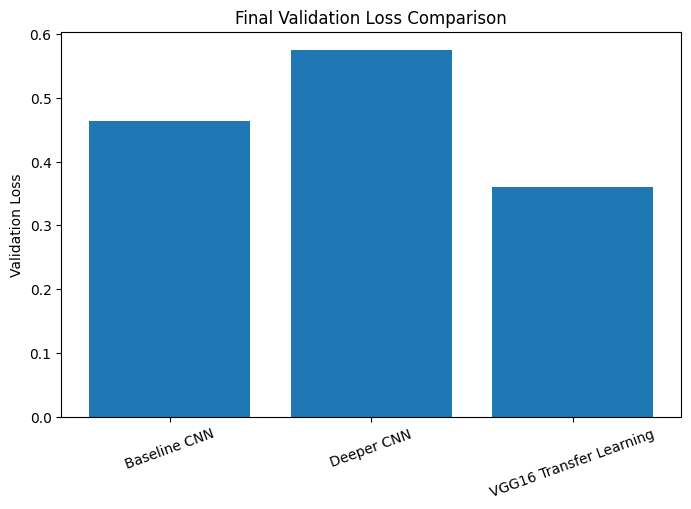

In [34]:
# Final Performance Comparison of All Models
# Run this cell after Baseline CNN, Deeper CNN, and Transfer Learning models are trained

import matplotlib.pyplot as plt

# Get best validation accuracy and loss from each model history
baseline_best_acc = max(history.history['val_accuracy'])
baseline_best_loss = min(history.history['val_loss'])

deeper_best_acc = max(history2.history['val_accuracy'])
deeper_best_loss = min(history2.history['val_loss'])

transfer_best_acc = max(history3.history['val_accuracy'])
transfer_best_loss = min(history3.history['val_loss'])

# Model names
models = ['Baseline CNN', 'Deeper CNN', 'VGG16 Transfer Learning']

# Accuracy and loss values
accuracies = [baseline_best_acc, deeper_best_acc, transfer_best_acc]
losses = [baseline_best_loss, deeper_best_loss, transfer_best_loss]

# Print comparison table
print("Final Model Performance Comparison")
print("----------------------------------")
print(f"Baseline CNN              - Best Val Accuracy: {baseline_best_acc:.4f}, Best Val Loss: {baseline_best_loss:.4f}")
print(f"Deeper CNN                - Best Val Accuracy: {deeper_best_acc:.4f}, Best Val Loss: {deeper_best_loss:.4f}")
print(f"VGG16 Transfer Learning   - Best Val Accuracy: {transfer_best_acc:.4f}, Best Val Loss: {transfer_best_loss:.4f}")

# Plot validation accuracy comparison
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.title("Final Validation Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

# Plot validation loss comparison
plt.figure(figsize=(8, 5))
plt.bar(models, losses)
plt.title("Final Validation Loss Comparison")
plt.ylabel("Validation Loss")
plt.xticks(rotation=20)
plt.show()

Baseline vs Deeper Cost Comparison